# CoQA Dataset Exploration

Conversational Question Answering (~109K train + ~8K val QA turns across ~7.7K dialogues).  
Abstractive-friendly conversational QnA across 5 domains (race, cnn, wikipedia, gutenberg, mctest).  
~82% of answers are abstractive (don't exactly match the extractive span); ~1.3% are "unknown" (unanswerable).  
HuggingFace: `stanfordnlp/coqa`

Columns: `source` (domain), `story` (context), `questions` (list[str]), `answers` (list of {`input_text`, `answer_start`, `answer_end`})

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
from pathlib import Path
from pprint import pprint
import sys
from typing import Optional, List, Dict, Any, Tuple
if '..' not in sys.path: sys.path.append('..')

from datasets import load_dataset
from datasets.arrow_dataset import Dataset
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from transformers import AutoTokenizer, PreTrainedTokenizer

In [3]:
DATA_PATH = Path('Q:/data')
QNA_DATA_PATH = DATA_PATH / 'qna'
QNA_DATA_PATH.mkdir(parents=True, exist_ok=True)

COQA_HF_ID = 'stanfordnlp/coqa'
tkz = AutoTokenizer.from_pretrained('bert-base-uncased')
print(f'DATA_PATH: {DATA_PATH}')
print(f'COQA_HF_ID: {COQA_HF_ID}')
print(f'Tokenizer vocab size: {tkz.vocab_size}')

DATA_PATH: Q:\data
COQA_HF_ID: stanfordnlp/coqa
Tokenizer vocab size: 30522


## Load CoQA

In [4]:
# Load CoQA from HuggingFace
ds_coqa = load_dataset(COQA_HF_ID, cache_dir=str(DATA_PATH), trust_remote_code=True)
print(f'Splits: {list(ds_coqa.keys())}')
for split_name, split_ds in ds_coqa.items():
    n_turns = sum(len(split_ds[i]['questions']) for i in range(len(split_ds)))
    print(f'  {split_name}: {len(split_ds)} dialogues, {n_turns} QA turns')
print(f'\nFeatures: {list(ds_coqa["train"].features.keys())}')

Splits: ['train', 'validation']
  train: 7199 dialogues, 108647 QA turns
  validation: 500 dialogues, 7983 QA turns

Features: ['source', 'story', 'questions', 'answers']


In [7]:
# Examine the structure of one dialogue
ex = ds_coqa['train'][0]
print('Keys:', list(ex.keys()))
print()
print(f'source: {ex["source"]}')
print(f'story: {ex["story"][:300]}...')
print(f'Number of turns: {len(ex["questions"])}')
print()
for i in range(min(5, len(ex['questions']))):
    q = ex['questions'][i]
    ans_text = ex['answers']['input_text'][i]
    a_start = ex['answers']['answer_start'][i]
    a_end = ex['answers']['answer_end'][i]
    span = ex['story'][a_start:a_end]
    print(f'  Turn {i}: Q: "{q}"')
    print(f'           A (input_text): "{ans_text}"')

    print(f'           Span [{a_start}:{a_end}]: "{span[:120]}"')
    print()

Keys: ['source', 'story', 'questions', 'answers']

source: wikipedia
story: The Vatican Apostolic Library (), more commonly called the Vatican Library or simply the Vat, is the library of the Holy See, located in Vatican City. Formally established in 1475, although it is much older, it is one of the oldest libraries in the world and contains one of the most significant coll...
Number of turns: 20

  Turn 0: Q: "When was the Vat formally opened?"
           A (input_text): "It was formally established in 1475"
           Span [151:179]: "Formally established in 1475"

  Turn 1: Q: "what is the library for?"
           A (input_text): "research"
           Span [454:494]: "he Vatican Library is a research library"

  Turn 2: Q: "for what subjects?"
           A (input_text): "history, and law"
           Span [457:511]: "Vatican Library is a research library for history, law"

  Turn 3: Q: "and?"
           A (input_text): "philosophy, science and theology"
           Span [457:545]: "Va

## Dataset Statistics

In [8]:
# Dataset statistics
ds_train = ds_coqa['train']

n_dialogues = len(ds_train)
turns_per_dialogue = [len(ds_train[i]['questions']) for i in range(n_dialogues)]
total_turns = sum(turns_per_dialogue)

# Domain (source) distribution
from collections import Counter
source_counts = Counter(ds_train[i]['source'] for i in range(n_dialogues))

# Count "unknown" (unanswerable) answers
n_unknown = 0
n_exact_match = 0
for i in range(n_dialogues):
    for j in range(len(ds_train[i]['questions'])):
        ans_text = ds_train[i]['answers']['input_text'][j]
        if ans_text.lower().strip() == 'unknown':
            n_unknown += 1
        else:
            a_start = ds_train[i]['answers']['answer_start'][j]
            a_end = ds_train[i]['answers']['answer_end'][j]
            span = ds_train[i]['story'][a_start:a_end]
            if ans_text == span:
                n_exact_match += 1

n_answerable = total_turns - n_unknown
n_abstractive = n_answerable - n_exact_match

print(f'Train dialogues: {n_dialogues}')
print(f'Total QA turns: {total_turns}')
print(f'Avg turns per dialogue: {total_turns / n_dialogues:.1f}')
print(f'\nAnswerable turns: {n_answerable} ({n_answerable/total_turns:.1%})')
print(f'Unknown (unanswerable): {n_unknown} ({n_unknown/total_turns:.1%})')
print(f'Exact-match (extractive): {n_exact_match} ({n_exact_match/n_answerable:.1%} of answerable)')
print(f'Abstractive (input_text != span): {n_abstractive} ({n_abstractive/n_answerable:.1%} of answerable)')
print(f'\nSource domains:')
for src, cnt in source_counts.most_common():
    print(f'  {src}: {cnt} dialogues')

Train dialogues: 7199
Total QA turns: 108647
Avg turns per dialogue: 15.1

Answerable turns: 107271 (98.7%)
Unknown (unanswerable): 1376 (1.3%)
Exact-match (extractive): 19509 (18.2% of answerable)
Abstractive (input_text != span): 87762 (81.8% of answerable)

Source domains:
  race: 1711 dialogues
  cnn: 1702 dialogues
  wikipedia: 1621 dialogues
  gutenberg: 1615 dialogues
  mctest: 550 dialogues


Turns per dialogue: mean=15.1, median=16, min=1, max=36, std=5.2

Answer char lengths (answerable): mean=14.7, median=10, max=1819


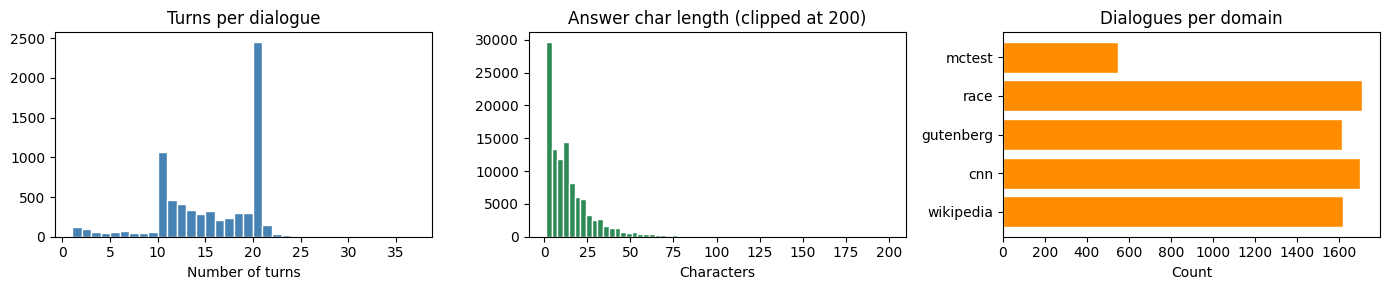

In [9]:
# Turns-per-dialogue and answer char-length distributions
turns_arr = np.array(turns_per_dialogue)
print(f'Turns per dialogue: mean={turns_arr.mean():.1f}, median={np.median(turns_arr):.0f}, '
      f'min={turns_arr.min()}, max={turns_arr.max()}, std={turns_arr.std():.1f}')

# Answer char length distribution (answerable only)
ans_char_lens = []
for i in range(n_dialogues):
    for j in range(len(ds_train[i]['questions'])):
        ans_text = ds_train[i]['answers']['input_text'][j]
        if ans_text.lower().strip() != 'unknown':
            ans_char_lens.append(len(ans_text))
ans_char_lens = np.array(ans_char_lens)
print(f'\nAnswer char lengths (answerable): mean={ans_char_lens.mean():.1f}, '
      f'median={np.median(ans_char_lens):.0f}, max={ans_char_lens.max()}')

fig, axes = plt.subplots(1, 3, figsize=(14, 3))
axes[0].hist(turns_arr, bins=range(1, turns_arr.max() + 2), color='steelblue', edgecolor='white')
axes[0].set_title('Turns per dialogue')
axes[0].set_xlabel('Number of turns')

axes[1].hist(np.clip(ans_char_lens, 0, 200), bins=60, color='seagreen', edgecolor='white')
axes[1].set_title('Answer char length (clipped at 200)')
axes[1].set_xlabel('Characters')

# Dialogues per source domain
domains = list(source_counts.keys())
counts = [source_counts[d] for d in domains]
axes[2].barh(domains, counts, color='darkorange', edgecolor='white')
axes[2].set_title('Dialogues per domain')
axes[2].set_xlabel('Count')

plt.tight_layout()
plt.show()

## Inspect Examples (Conversational Turns)

In [10]:
# Display a few full dialogues
for d_idx in range(3):
    ex = ds_train[d_idx]
    print(f'=== Dialogue {d_idx}: source={ex["source"]} ===')
    print(f'  Story: {ex["story"][:300]}...')
    print()

    n_turns = len(ex['questions'])
    for t_idx in range(n_turns):
        q = ex['questions'][t_idx]
        ans_text = ex['answers']['input_text'][t_idx]
        a_start = ex['answers']['answer_start'][t_idx]
        a_end = ex['answers']['answer_end'][t_idx]
        span = ex['story'][a_start:a_end]

        is_unknown = ans_text.lower().strip() == 'unknown'
        is_exact = ans_text == span
        tag = ' [UNKNOWN]' if is_unknown else (' [EXACT]' if is_exact else ' [ABSTRACTIVE]')

        # Show context around answer span
        if not is_unknown:
            ctx_off = 40
            beg = max(a_start - ctx_off, 0)
            ctx_around = ex['story'][beg:a_end + ctx_off]
            ctx_snip = f'  ...{ctx_around}...'
        else:
            ctx_snip = ''

        print(f'  Turn {t_idx}: Q: "{q}"')
        print(f'           A: "{ans_text[:150]}"{tag}')
        if not is_exact and not is_unknown:
            print(f'           Span: "{span[:150]}"')
        if ctx_snip:
            print(f'           Context: "{ctx_snip}"')
    print()

=== Dialogue 0: source=wikipedia ===
  Story: The Vatican Apostolic Library (), more commonly called the Vatican Library or simply the Vat, is the library of the Holy See, located in Vatican City. Formally established in 1475, although it is much older, it is one of the oldest libraries in the world and contains one of the most significant coll...

  Turn 0: Q: "When was the Vat formally opened?"
           A: "It was formally established in 1475" [ABSTRACTIVE]
           Span: "Formally established in 1475"
           Context: "  ... the Holy See, located in Vatican City. Formally established in 1475, although it is much older, it is one o..."
  Turn 1: Q: "what is the library for?"
           A: "research" [ABSTRACTIVE]
           Span: "he Vatican Library is a research library"
           Context: "  ...which include some 8,500 incunabula. 

The Vatican Library is a research library for history, law, philosophy, science a..."
  Turn 2: Q: "for what subjects?"
           A: "history,

## Flatten to Single-Turn QnA Pairs

In [11]:
# Flatten dialogues into single-turn (context, question, answer) rows
# CoQA answers are often abstractive — input_text differs from the extractive span
# We store both for analysis; for unified format we'll use input_text as the answer
rows_flat = []
for i in range(len(ds_train)):
    ex = ds_train[i]
    story = ex['story']
    for t_idx in range(len(ex['questions'])):
        question = ex['questions'][t_idx]
        ans_text = ex['answers']['input_text'][t_idx]
        a_start = ex['answers']['answer_start'][t_idx]
        a_end = ex['answers']['answer_end'][t_idx]
        span = story[a_start:a_end]
        is_unknown = ans_text.lower().strip() == 'unknown'
        rows_flat.append({
            'context': story,
            'question': question,
            'answer': ans_text,
            'span': span,
            'answer_start': a_start,
            'answer_end': a_end,
            'is_unanswerable': is_unknown,
            'is_exact': ans_text == span,
            'source_domain': ex['source'],
            'turn_idx': t_idx,
        })

df_flat = pd.DataFrame(rows_flat)
n_answerable = (~df_flat['is_unanswerable']).sum()
n_exact = df_flat['is_exact'].sum()
print(f'Flattened rows: {len(df_flat)}')
print(f'  Answerable: {n_answerable} ({n_answerable/len(df_flat):.1%})')
print(f'  Unanswerable (unknown): {df_flat["is_unanswerable"].sum()} ({df_flat["is_unanswerable"].mean():.1%})')
print(f'  Exact match (extractive): {n_exact} ({n_exact/n_answerable:.1%} of answerable)')
print()
df_flat.head(10)

Flattened rows: 108647
  Answerable: 107271 (98.7%)
  Unanswerable (unknown): 1376 (1.3%)
  Exact match (extractive): 19509 (18.2% of answerable)



,context,question,answer,span,answer_start,answer_end,is_unanswerable,is_exact,source_domain,turn_idx
0,"The Vatican Apostolic Library (), more commonl...",When was the Vat formally opened?,It was formally established in 1475,Formally established in 1475,151,179,False,False,wikipedia,0
1,"The Vatican Apostolic Library (), more commonl...",what is the library for?,research,he Vatican Library is a research library,454,494,False,False,wikipedia,1
2,"The Vatican Apostolic Library (), more commonl...",for what subjects?,"history, and law",Vatican Library is a research library for hist...,457,511,False,False,wikipedia,2
3,"The Vatican Apostolic Library (), more commonl...",and?,"philosophy, science and theology",Vatican Library is a research library for hist...,457,545,False,False,wikipedia,3
4,"The Vatican Apostolic Library (), more commonl...",what was started in 2014?,a project,"March 2014, the Vatican Library began an initi...",769,879,False,False,wikipedia,4
5,"The Vatican Apostolic Library (), more commonl...",how do scholars divide the library?,into periods,Scholars have traditionally divided the histor...,1048,1127,False,False,wikipedia,5
6,"The Vatican Apostolic Library (), more commonl...",how many?,five,Scholars have traditionally divided the histor...,1048,1128,False,False,wikipedia,6
7,"The Vatican Apostolic Library (), more commonl...",what is the official name of the Vat?,The Vatican Apostolic Library,"Vatican Apostolic Library (), more commonly ca...",4,94,False,False,wikipedia,7
8,"The Vatican Apostolic Library (), more commonl...",where is it?,in Vatican City,"is the library of the Holy See, located in Vat...",94,150,False,False,wikipedia,8
9,"The Vatican Apostolic Library (), more commonl...",how many printed books does it contain?,1.1 million,"It has 75,000 codices from throughout history...",328,412,False,False,wikipedia,9


In [12]:
# Verify extractive spans: for exact-match rows, confirm span matches context
df_exact = df_flat[df_flat['is_exact'] & ~df_flat['is_unanswerable']].copy()
n_mismatch = 0
for _, row in df_exact.head(5000).iterrows():
    ctx = row['context']
    start, end = row['answer_start'], row['answer_end']
    extracted = ctx[start:end]
    if extracted != row['answer']:
        n_mismatch += 1
        if n_mismatch <= 3:
            print(f'MISMATCH: extracted="{extracted[:80]}" vs answer="{row["answer"][:80]}"')

print(f'Span mismatches in exact-match rows (first 5000): {n_mismatch}')

# Abstractive examples: show how input_text differs from span
print('\nAbstractive examples (input_text vs span):')
df_abstract = df_flat[~df_flat['is_exact'] & ~df_flat['is_unanswerable']]
for _, row in df_abstract.head(5).iterrows():
    print(f'  Q: "{row["question"]}"')
    print(f'  input_text: "{row["answer"][:100]}"')
    print(f'  span:       "{row["span"][:100]}"')
    print()

Span mismatches in exact-match rows (first 5000): 0

Abstractive examples (input_text vs span):
  Q: "When was the Vat formally opened?"
  input_text: "It was formally established in 1475"
  span:       "Formally established in 1475"

  Q: "what is the library for?"
  input_text: "research"
  span:       "he Vatican Library is a research library"

  Q: "for what subjects?"
  input_text: "history, and law"
  span:       "Vatican Library is a research library for history, law"

  Q: "and?"
  input_text: "philosophy, science and theology"
  span:       "Vatican Library is a research library for history, law, philosophy, science and theology"

  Q: "what was started in 2014?"
  input_text: "a  project"
  span:       "March 2014, the Vatican Library began an initial four-year project of digitising its collection of m"



## Context / Answer Length Distributions

In [13]:
# Tokenize contexts, questions, answers and measure lengths (answerable only)
df_ans = df_flat[~df_flat['is_unanswerable']].reset_index(drop=True)

coqa_ctx_lens = []
coqa_q_lens = []
coqa_ans_lens = []

for _, row in df_ans.iterrows():
    ctx_toks = tkz(row['context'], add_special_tokens=False).input_ids
    q_toks = tkz(row['question'], add_special_tokens=False).input_ids
    ans_toks = tkz(row['answer'], add_special_tokens=False).input_ids

    coqa_ctx_lens.append(len(ctx_toks))
    coqa_q_lens.append(len(q_toks))
    coqa_ans_lens.append(len(ans_toks))

coqa_ctx_lens = np.array(coqa_ctx_lens)
coqa_q_lens = np.array(coqa_q_lens)
coqa_ans_lens = np.array(coqa_ans_lens)

print(f'Processed {len(coqa_ctx_lens)} answerable examples')
print('\nContext token lengths:')
print(f'  mean={coqa_ctx_lens.mean():.1f}, median={np.median(coqa_ctx_lens):.1f}, '
      f'min={coqa_ctx_lens.min()}, max={coqa_ctx_lens.max()}, std={coqa_ctx_lens.std():.1f}')
print('Question token lengths:')
print(f'  mean={coqa_q_lens.mean():.1f}, median={np.median(coqa_q_lens):.1f}, '
      f'min={coqa_q_lens.min()}, max={coqa_q_lens.max()}, std={coqa_q_lens.std():.1f}')
print('Answer token lengths:')
print(f'  mean={coqa_ans_lens.mean():.1f}, median={np.median(coqa_ans_lens):.1f}, '
      f'min={coqa_ans_lens.min()}, max={coqa_ans_lens.max()}, std={coqa_ans_lens.std():.1f}')

Token indices sequence length is longer than the specified maximum sequence length for this model (696 > 512). Running this sequence through the model will result in indexing errors


Processed 107271 answerable examples

Context token lengths:
  mean=350.6, median=349.0, min=87, max=1322, std=83.3
Question token lengths:
  mean=6.7, median=6.0, min=1, max=51, std=2.7
Answer token lengths:
  mean=3.3, median=2.0, min=1, max=425, std=3.7


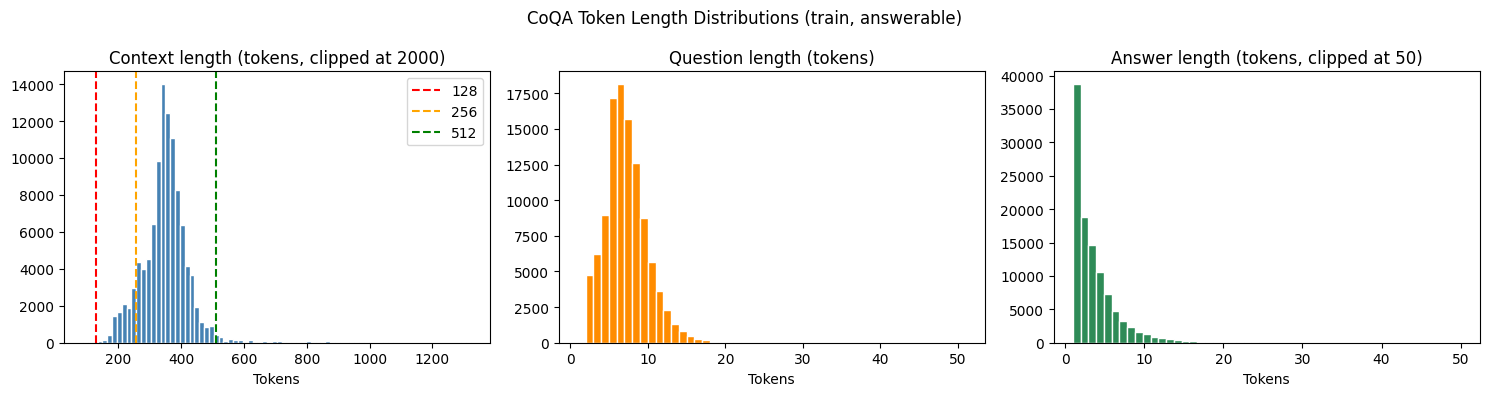

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Context lengths — clip at 2000
ctx_clip = np.clip(coqa_ctx_lens, 0, 2000)
axes[0].hist(ctx_clip, bins=80, color='steelblue', edgecolor='white')
axes[0].set_title('Context length (tokens, clipped at 2000)')
axes[0].set_xlabel('Tokens')
axes[0].axvline(128, color='red', linestyle='--', label='128')
axes[0].axvline(256, color='orange', linestyle='--', label='256')
axes[0].axvline(512, color='green', linestyle='--', label='512')
axes[0].legend()

axes[1].hist(coqa_q_lens, bins=50, color='darkorange', edgecolor='white')
axes[1].set_title('Question length (tokens)')
axes[1].set_xlabel('Tokens')

axes[2].hist(np.clip(coqa_ans_lens, 0, 50), bins=50, color='seagreen', edgecolor='white')
axes[2].set_title('Answer length (tokens, clipped at 50)')
axes[2].set_xlabel('Tokens')

plt.suptitle('CoQA Token Length Distributions (train, answerable)')
plt.tight_layout()
plt.show()

In [15]:
# Chunk analysis — how many contexts need multi-chunk processing
for inp_len in [128, 256, 384, 512]:
    chunk_content = inp_len - 2
    n_chunks = np.ceil(coqa_ctx_lens / chunk_content).astype(int)
    multi = (n_chunks > 1).sum()
    print(f'inp_len={inp_len}: need >1 chunk: {multi}/{len(coqa_ctx_lens)} ({multi/len(coqa_ctx_lens):.1%}), '
          f'max chunks: {n_chunks.max()}, mean chunks: {n_chunks.mean():.2f}')

inp_len=128: need >1 chunk: 107161/107271 (99.9%), max chunks: 11, mean chunks: 3.24
inp_len=256: need >1 chunk: 96946/107271 (90.4%), max chunks: 6, mean chunks: 1.93
inp_len=384: need >1 chunk: 28903/107271 (26.9%), max chunks: 4, mean chunks: 1.28
inp_len=512: need >1 chunk: 2476/107271 (2.3%), max chunks: 3, mean chunks: 1.02


## Convert to Unified QnA Format

In [ ]:
# Convert CoQA to unified QnA format: (context, question, answer, source)
# Combine train + validation splits; skip "unknown" answers
# Use input_text as the answer (abstractive, as provided by annotators)
rows_unified = []
for split_name in ds_coqa.keys():
    ds_split = ds_coqa[split_name]
    for i in range(len(ds_split)):
        ex = ds_split[i]
        story = ex['story']
        for t_idx in range(len(ex['questions'])):
            question = ex['questions'][t_idx]
            ans_text = ex['answers']['input_text'][t_idx]
            if ans_text.lower().strip() == 'unknown' or not story.strip() or not question.strip():
                continue
            rows_unified.append({
                'context': story,
                'question': question,
                'answer': ans_text,
                'source': 'coqa',
            })

df_unified_coqa = pd.DataFrame(rows_unified)
print(f'Unified CoQA rows (all splits, answerable only): {len(df_unified_coqa)}')
df_unified_coqa.head()

In [ ]:
# Save unified format
unified_fpath = QNA_DATA_PATH / 'coqa_unified.parquet'
df_unified_coqa.to_parquet(unified_fpath, index=False)
print(f'Saved to {unified_fpath} ({len(df_unified_coqa)} rows)')